
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

1. Importamos librerías necesarias para trabajar
2. Crearemos DataFrames para cada conjunto de datos
3. Mostramos información detallada de cada DataFrame con info() y head(), así corroboramos que se hayan creado correctamente los dfs y que la data sea consistente

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La sección del Paso 1 “Plan” sigue siendo el placeholder de la plantilla. Considera añadir un plan breve que describa (1) cómo vas a leer los CSV no estándar (p. ej., delimiter), y (2) qué comprobaciones iniciales vas a ejecutar (`.info()`, `.head()`, dtypes esperados, valores faltantes, duplicados) antes de pasar al preprocesamiento.

</div>


In [1]:
# importar librerías
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:

# leer conjuntos de datos en los DataFrames
"""Primero crearemos los DaraFrames correspondientes con el objetivo de 
dar un vistazo general a la estructura de datos, los tipos de los mismos,
si se requiere además de usar algún parámetro adicional en la función read_csv,
como es el caso de estas bases de datos, al no estar en realidad separadas por
comas como sugiere la extensión de cada ruta. Adicional, es nuestro objetivo
dimensionar el tamaño de los DataFrames y ver valores ausentes
"""
# usamos argumento "sep" para separar por ";"
inst_orders_df = pd.read_csv("/datasets/instacart_orders.csv", sep=";") 
products_df = pd.read_csv("/datasets/products.csv",sep=";")
aisles_df = pd.read_csv("/datasets/aisles.csv",sep=";")
departments_df = pd.read_csv("/datasets/departments.csv",sep=";")
order_products_df = pd.read_csv("/datasets/order_products.csv", sep=";")


- Acá notamos que el tipo de datos de la columna "days_since_prior_order"
es "float", sin embargo, es más adecuado que sea entero
- También notamos al rededor de ~280000 datos ausentes en esta misma columna.
Estos deben ser llenados con un valor que no afecte los cálculos que haremos

In [3]:
# mostrar información del DataFrame
print(inst_orders_df.info())
print()
print(inst_orders_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                

In [4]:

# mostrar información del DataFrame
print(products_df.info())
print()
print(products_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             

La única columna con valores ausentes en est df es product_name

In [5]:
# mostrar información del DataFrame
print(aisles_df.info())
print()
print(aisles_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


No hay mayor novedad acá, los datos de cada columna tienen el tipo y formato correctos

In [6]:
# mostrar información del DataFrame
print(departments_df.info())
print()
print(departments_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None

   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


In [7]:
# mostrar información del DataFrame
print(order_products_df.info())
print()
print(order_products_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

### Estructura y tipo de datos
- La principal novedad identificada es que los datos no están en realidad separados por comas sino por ";", por lo que utilizamos el parámetro "sep=";"" para garantizar que se podían visualizar los datos.
- En cuanto a tipos de datos, la mayoría son correctos, solo una pequeña apreciación en la columna "days_since_prior_order" del df "ins_orders_df" puesto que es de tipo float y pudiera ser entero. Sin embargo, al sder tipo numérico no debería haber problemas en los cálculos
- La columna add_to_cart_order del df order_products_df order_products_df es de tipo flotante también. Este se puede convertir a enero porque habla de un orden secuancial de añadido al carrito
### Valores ausentes y duplicados
- En este preprocesamiento apenas identificamos valores ausentes. Según el orden del proyecto, en el siguiente paso veremos a profuncidad eso y los valores duoplicados, Sin embargo, por el método info() ya identificamos ausentes en los dfs:
    - inst_orders_df
    - products_df


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La sección de conclusiones del Paso 1 sigue siendo el marcador de posición (placeholder) de la plantilla. Considera resumir tus principales conclusiones de la carga/inspección de datos (tamaños de las tablas, qué columnas tienen valores faltantes y cualquier preocupación sobre `dtype`, como columnas `float` que representan conteos/posiciones de orden).

</div>


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

### Plan

- Para este paso es necesario usar métodos que conviertan los tipos de datos, pasando float a int con la función integrada "int".
- Respecto a los alores ausentes, usaremos el método fillna() y reemplazaremos dichos valores por 0 o por un valor categórico que permita diferenciar estos de los demás en el caso de las columnas de tipo object
- Los valores duplicados, serán removidos con el método drop_duplicates()

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
# Usamos un f-string para imprimir un mensaje que muestre el conteo de duplicados usando los métodos duplicated y sum
print(f'Cantidad de duplicados en inst_orders_df: {inst_orders_df.duplicated().sum()}')

Cantidad de duplicados en inst_orders_df: 15


In [9]:
# verificamos los duplicados del primer df almacenándolos en una variable y luego imprmiéndola
duplicadas = inst_orders_df[inst_orders_df.duplicated(keep=False)] # filtramos el df mediante una máscara booleana y asignamos el atributo False al parámetro keep= para mantener los duplicados en el filtro
print(duplicadas)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   
164581   1112182   202304            84          3                  2   
200059   1782114   106752             1          3                  2   
204042   2125197    14050            48          3                  2   
215294   2160484   107525            16          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
242618   1021560    53767             3          3                  2   
250626    467134    63189            21          3 

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
- Solo el df inst_orders_df tiene 15 duplicados. Al revisar los datos a detalle, identificamos que todos los duplicados corresponden al mismo día y la misma hora (miércoles 2 am). Se eliminan los duplicados con el método drop_duplicates
### Razonamiento
1. Primero buscamos establecer una cantidad de duplicados, para esto combinamos los métodos duplicated() y sum()
2. Luego mostramos los duplicados solo con el método duplicated() y un print
3. Revisamos los datos con detenimiento para encontrar patrones
4. Se determina que los registros son duplicados exactos, así que se eliminarán con el método drop_duplicates


In [10]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
# Usamos una consulta para imprimir las órdenes realizadas el día miércoles a las 2 de la mañana y lo contabilizamos con el método count()

inst_orders_filtered_wed_2_am = inst_orders_df.query("order_dow == 3 & order_hour_of_day == 2").shape[0]
# Ahora calcularemos la participación de las órdenes realizadas a esta hora vs el total de órdenes de este día
# anticipamos que será una baja participación, considerando la hora y el día de la semana, el cuál suele ser un día en la que la vida nocturna no es muy activa
total_orders_wed = inst_orders_df.query("order_dow == 3").shape[0]
participacion_wed_2_am = (inst_orders_filtered_wed_2_am / total_orders_wed) * 100
print(f"La participación de las órdenes del miércoles a las 2 de la mañana es {participacion_wed_2_am:.2f}% con {inst_orders_filtered_wed_2_am} órdenes recibidas")


La participación de las órdenes del miércoles a las 2 de la mañana es 0.20% con 121 órdenes recibidas


¿Qué sugiere este resultado?

- El resultado sugiere que la participación de las órdenes en este día a esta hora en específico es muy baja. por otro lado, parece haber un error en la plataforma uno de los miércoles a las 2 am que causó una duplicidad en órdenes, puesto que, todos los 15 duplicados encontrados unas líneas de código arriba, encajaban con estas 2 condiciones

In [11]:
# Elimina los pedidos duplicados
inst_orders_df.drop_duplicates(inplace=True)
# Se elimina código que elimina duplicados antes de investigar registros del miércoles 2 am


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu investigación sobre órdenes duplicadas se vuelve inconsistente porque los duplicados se eliminan antes de que termines de validar el patrón de “Wednesday at 2am”. Considera primero inspeccionar/confirmar el subconjunto sospechoso sobre los datos originales, interpretar lo que sugiere y solo después eliminar los duplicados (una sola vez), para que tu análisis coincida con la secuencia solicitada.

</div>


In [12]:
# Vuelve a verificar si hay filas duplicadas
print(f"Total duplicados: {inst_orders_df.duplicated().sum()}")

Total duplicados: 0


In [13]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos

print(f"Cantidad de IDs de órdenes duplicadas: {inst_orders_df['order_id'].duplicated().sum()}")

Cantidad de IDs de órdenes duplicadas: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos

- En los últimos 3 cuadros de código, después de eliminar duplicados (identificado el problema del miércoles 2 am) y calcular pa participación y cantidad de órdenes de ese intervalo, lo que hicimos fue volver a contar duplicados y, además, como segundo método de validación, revisamos si habían IDs de órdenes duplicadas. Arrojando un resultado de 0

### `products` data frame

In [14]:
# Verifica si hay filas totalmente duplicadas
print(f'Cantidad de filas duplicadas en products_df: {products_df.duplicated().sum()}')

Cantidad de filas duplicadas en products_df: 0


In [15]:
# Revisa únicamente si hay ID de productos duplicados
print(f"Cantidad de IDs de productos duplicados: {products_df['product_id'].duplicated().sum()}")

Cantidad de IDs de productos duplicados: 0


In [16]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products_df['product_name_mayus'] = products_df['product_name'].str.upper() # convertimos a mayúsuclas todos los nombres de productos en una columna adicional para evitar alterar la columna original
duplicated_products = products_df['product_name'].duplicated().sum() # contabilizamos los duplicados
print(f"Cantidad de nombres de productos duplicados: {duplicated_products}") # Imprimimos conteo

Cantidad de nombres de productos duplicados: 1257


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Convertir `product_name` a mayúsculas *in-place* cambia permanentemente el dataset que usarás más adelante. Considera crear una Series temporal en mayúsculas (o una columna auxiliar) solo para la verificación de duplicados, y mantener intactos los valores originales de `product_name` para el análisis/salida posteriores.

</div>


In [17]:
# Revisa si hay nombres duplicados de productos no faltantes
"""Vamos a crear un objeto Series que almacenaremos en una variable para filtrar 
la columna product_name, aplicando el método dropna() para que los valores NaN no se 
cuenten como duplicados
"""
non_nan_values = products_df['product_name'].dropna()
# ahora contamos duplicados dentro de este objeto Series
duplicates_non_nan_values = non_nan_values.duplicated().sum()
print(f"Duplicados sin contabilizar NaN: {duplicates_non_nan_values}")


Duplicados sin contabilizar NaN: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

- Inicialmente no encontramos duplicados a nivel de filas completas ni filtrando por id de los productos
- Al revisar por nombre de producto. contabilizamos 1258 sin convertir a mayúsculas los nombres, luego de convertirlos a mayúscula, la cifra alcanzó 1361.
- Posteriormente, contabilizamos duplicados eliminando los valores NaN del conteo, lo que arrojó un total de 104. Lo que quiere decir que los métodos .duplicated().sum() contabilizan estos como duplicados reales
- Un detalle importante que noté es que, al revisar si habían IDs de producto duplicados, el resultado fue 0, sin embargo, sí existen nombres de producto duplicados. Esto podría sugerir que un mismo producto puede venir de distintos proveedores y,tener clara esta distinción, podría ser útil si queremos analizar el rendimiento de un proveedor vs otros en términos de costos o calidad del producto acorde a su rotación


### `departments` data frame

In [18]:
# Revisa si hay filas totalmente duplicadas
print(f'Cantidad de duplicados en departments_df: {departments_df.duplicated().sum()}')

Cantidad de duplicados en departments_df: 0


In [19]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(f"Cantidad de duplicados en departments_df: {departments_df['department_id'].duplicated().sum()}")

Cantidad de duplicados en departments_df: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No existen IDs de departamentos duplicados ni duplicados en el total de las filas. no se ejecuta acción hasta el momento sobre este DF

### `aisles` data frame

In [20]:
# Revisa si hay filas totalmente duplicadas
print(f'Cantidad de duplicados en aisles_df: {aisles_df.duplicated().sum()}')

Cantidad de duplicados en aisles_df: 0


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo con las comprobaciones de `aisles`: verificaste tanto duplicados de filas completas como `aisle_id`s duplicados y concluíste claramente que no era necesario realizar ninguna acción.

</div>


In [21]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(f"Cantidad de duplicados en aisles_df: {aisles_df['aisle_id'].duplicated().sum()}")

Cantidad de duplicados en aisles_df: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al igual que en el df de departments, no se encuentran duplicados en este df a nivel de filas ni de IDs

### `order_products` data frame

In [22]:
# Revisa si hay filas totalmente duplicadas
print(f'Cantidad de duplicados en order_products_df: {order_products_df.duplicated().sum()}')

Cantidad de duplicados en order_products_df: 0


In [23]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(f'Cantidad de duplicados en order_products_df, filtrando solo por order_id: {order_products_df["order_id"].duplicated().sum()}')

Cantidad de duplicados en order_products_df, filtrando solo por order_id: 4094961


Describe brevemente tus hallazgos y lo que hiciste con ellos.

- Este DataFrame tiene una particularidad y es que un order_id aparece múltiples veces, como en la línea de código inmediatamente superior, la cual arroja más de 4 millones de duplicados. Pasaría lo mismo si filtramos por product_id. no obstante, no necesariamente son duplicados puesto que un producto puede ser comprado múltiples veces por el mismo cliente o inclusive diferentes clientes. Por otro lado, el mismo order_id puede aparecer múltiples veces porque una misma orden tiene varios productos. Entonces, acá los duplicados se identifican es si todas las columnas son idénticas, puesto que, al ser columnas con tipos de datos numéricos, no existen métodos de normalización de texto como en los strings que podamos usar para identificar duplicados engañosos, como pasa cuando el texto es el mismo pero hay diferencia entre mayúsculas-minúsculas.
En ese orden de ideeas, la primera revisión de duplicados de este Dataframe es asertada y muestra que no existen duplicados

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [24]:
# Encuentra los valores ausentes en la columna 'product_name'
empty_values_products = products_df["product_name"].isna().sum() # contamos valores ausentes y los almacenamos en una variable
print(f"Cantidad de valores ausentes en products_df: {empty_values_products}") # Imprimimos cantidad de ausentes
print(f"Total registros de Dataframe: {len(products_df)}") # Dimensionamos el tamaño del datarame
porcentaje = (empty_values_products / len(products_df)) * 100 # Calculamos la participación de los ausentes
print(f"Porcentaje de valores ausentes: {porcentaje:.2f}%") # Imporfamos la participación de los ausentes vs el total de registros en el df

Cantidad de valores ausentes en products_df: 1258
Total registros de Dataframe: 49694
Porcentaje de valores ausentes: 2.53%


Describe brevemente cuáles son tus hallazgos.
- La cantidad de valores ausentes en esta columna es significativa, supera el 2,5% con más de 1200 celdas
- Es necesario analizar el contenido de las demás columnas para determinar si se deben diligenciar estas celdas con algún dato categórico o, por el contrario, estas filas deben ser eliminadas para evitar sesgos en la data por falta de información

In [25]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
df_empty_products_name = products_df[products_df["product_name"].isna()]
aisle_100_validator = df_empty_products_name[df_empty_products_name["aisle_id"] == 100].shape[0]
print(f"Cantidad de ausentes cuyo pasillo es igual al id 100: {aisle_100_validator}")

Cantidad de ausentes cuyo pasillo es igual al id 100: 1258


Describe brevemente cuáles son tus hallazgos.

- Primero filtramos el DataFrame para identificar los registros con valores ausentes y luego revisamos si estos tienen como pasillo, aquel cuyo ID es = 100, lo cual es verdadero, por ende, existe un problema desde el registro de los productos de dicho pasillo, el cual está impidiendo una correcta investigación respecto a estos productos específicos.

In [26]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
aisle_21_validator = df_empty_products_name[df_empty_products_name["department_id"] == 21].shape[0]
print(f"Cantidad de ausentes cuyo departamento es igual al ID 21: {aisle_21_validator}")

Cantidad de ausentes cuyo departamento es igual al ID 21: 1258


Describe brevemente cuáles son tus hallazgos.

- La cantidad de registros ausentes en el departamento 21 coincide con la cantidad de valores ausentes en el pasillo 100

In [27]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
# Filtramos el df departments_df para ver el ID 21 en la columna "department_id" y, con el método iloc[] extraemos solo el valor con el índice 0
print(f"El departamento 21 es: {departments_df[departments_df['department_id']==21]['department'].iloc[0]}")
# de igual manera para los pasillos, id 100 en aisle_id e índice 0 en el método iloc  para traer solo el valor
print(f"El pasillo 100 es: {aisles_df[aisles_df['aisle_id']==100]['aisle'].iloc[0]}")

El departamento 21 es: missing
El pasillo 100 es: missing


Describe brevemente cuáles son tus hallazgos.

- Estos 1258 registros pertenecen no solo al pasillo con ID 100 sino al departamento 21. Al indagar en los DataFrames aisles_df y departments_df mediante una máscara booleana que nos muestre la columna que tiene el nombre en cada DataFrame, vemos que están categorizados como "missing", lo que sugiere que son órdenes reportadas como perdidas, algo muy común en esta industria por diversas razones (producto no entregado, el repartidor no llegó con la orden, etc)

In [28]:
# Completa los nombres de productos ausentes con 'Unknown'
products_df["product_name"].fillna("Unknown",inplace=True) # Usamos método fillna para llenar los valores ausentes
unkown_count = products_df[products_df["product_name"]=="Unknown"].count().iloc[0] # contamos cantidad de valores marcados como "Unknown"
print(f"Valores 'Unkown' luego de diligenciar campos vacíos: {unkown_count}") # Imprimimos resultado

Valores 'Unkown' luego de diligenciar campos vacíos: 1258


Describe brevemente tus hallazgos y lo que hiciste con ellos.

- Rellenamos los valores ausentes con el método fillna sobre la columna product_name en el DataFrame products_df
- Luego de eso contabilizamos los valores marcados como "Unknown" y lo almacenamos en una variable "unknown_count"
- Imprimimos el resultado y confimarmos que son 1258 los valores que ahora están descritos de esa manera en el DataFrame

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Sólida investigación de valores faltantes para `product_name`: cuantificaste la ausencia de datos, confirmaste que todos los nombres faltantes se asignan a aisle_id=100 y department_id=21, validaste esas etiquetas mediante las tablas de búsqueda, y completaste con un placeholder claro mientras documentabas el impacto.

</div>


### `orders` data frame

In [29]:
# Encuentra los valores ausentes
empty_values_orders = inst_orders_df["days_since_prior_order"].isna().sum()
print(f"Cantidad de valores ausentes en este DataFrame: {empty_values_orders} de {len(inst_orders_df)} registros totales ({empty_values_orders/len(inst_orders_df)*100:.2f})%")
# Para evitar que la columna "days_since_prior_order" sufra alteraciones en las medidas estadísticas, se mantienen los valores ausentes como NaN
inst_orders_df[inst_orders_df["days_since_prior_order"].isna()] # Imprimimos DataFrame para comprobar que los 28817 valores permanezcan como NaN

Cantidad de valores ausentes en este DataFrame: 28817 de 478952 registros totales (6.02)%


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Identificaste correctamente que los `days_since_prior_order` faltantes corresponden a los primeros pedidos, pero el notebook nunca aplica una decisión explícita de tratamiento para esos valores faltantes. Considera documentar y aplicar una estrategia (p. ej., completar los primeros pedidos con un valor significativo y explicar por qué, o mantener NaN con una justificación clara) y luego verificar el resultado.

</div>


In [30]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
df_filtered_days_since_prior_order = inst_orders_df[inst_orders_df["days_since_prior_order"].isna()]
result = df_filtered_days_since_prior_order.query("order_number > 1")
print(f"Pedidos con valores ausentes en 'days_since_prior_order' cuyo pedido no es el primero: {len(result)}")

Pedidos con valores ausentes en 'days_since_prior_order' cuyo pedido no es el primero: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

- A través de un filtro con el método isna() identificamos que los valores ausentes en el df inst_orders es equivalente al 6,02%. Esto al revisar específicamente la columna "days_since_priot_order". Al revisar estos valores ausentes con más detalle, identificamos que de estos valores ausentes, no hay ninguno que haya hecho más de una orden, lo cual tiene mucho sentido puesto que la columna con la que filtramos, de por sí, señala la cantidad de días vs órdenes anteriores para el mismo cliente. Esto sugiere que son clientes nuevos, lo cual podría representar una medida de crecimiento si se filtra además por fecha, para determinar cuántos de ellos corresponden a periodos de tiempo recientes

### `order_products` data frame

In [31]:
# Encuentra los valores ausentes
empty_values_order_products = (order_products_df["add_to_cart_order"].isna().sum())
print(empty_values_order_products)

836


In [32]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
min_order = order_products_df["add_to_cart_order"].min()
print(f"el valor mínimo para la columna 'add_to_cart_order' es: {min_order}")
max_order = order_products_df["add_to_cart_order"].max()
print(f"el valor máximo para la columna 'add_to_cart_order' es: {max_order}")

el valor mínimo para la columna 'add_to_cart_order' es: 1.0
el valor máximo para la columna 'add_to_cart_order' es: 64.0


Describe brevemente cuáles son tus hallazgos.

- Vemos que el total de valores ausentes en la columna add_to_cart_order es de 836. Además, el valor mínimo y máximo en esta columna es de 1 y 64 respectivamente.
- La información registrada en esta columna nos sirve para identificar tipos de clientes en función de su actividad de compra, aquellos con valores más bajos pue3den ser objetivo de estrategias publicitarias y descuentos acorde a sus intereses personales, adicional, pueden ser fuente de información valiosa respecto al producto en sí, nuestra plataforma, su usabilidad, la variedad de productos disponibles, la cobertura de nuestra logística, etc, esto con el objetivo de entender qué decisiones de negocio debemos tomar para fomentar un aumento en los índices de compra.
- Por otro lado, aquellos que tienen una mayor cantidad de productos comprados/agregados al carrito, son nuestros clientes más fieles y pueden ser objetivo para nuevos lanzamientos exclusivos, con el objetivo que se sientan parte de la marca y que las primicias son para ellos premiando su fidelidad

In [33]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
# Creamos una máscara booleana y alamecenamos en una variable los IDs producidos en el filtrado de datos con la máscara
order_id_series = order_products_df[order_products_df["add_to_cart_order"].isna()]["order_id"]
print(order_id_series)


737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [34]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.

# Primero filtramos el df por ausentes en la columna "add_to_cart_order" y agrupamos por "order_id"
grouped_by_order_id = order_products_df[order_products_df["add_to_cart_order"].isna()].groupby("order_id")["product_id"].count()
print(grouped_by_order_id) # imprimimos el resultado
# Vamos a cruzar los DataFrames order_products_df e inst_orders_df para ver si podemos encontar algún patrón
data_faltante = order_products_df[order_products_df["add_to_cart_order"].isna()] # creamos variable y filtramos por solo los vacíos en "add_to_cart_order"
df_merged = data_faltante.merge(inst_orders_df, on="order_id", how="inner") # usamos método merge parta fusionar los DataFrames, escogemos tipo inner para que solo nos deje los 836 registros y nos extienda las columnas para tener más info
print(df_merged.groupby("order_dow")['user_id'].count()) #  imprimimos por día de la semana
print(df_merged.groupby("order_hour_of_day")['user_id'].count()) # imprimimos por hora del día

order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64
order_dow
0     49
1    204
2    167
3    128
4     14
5    245
6     29
Name: user_id, dtype: int64
order_hour_of_day
0      26
1      34
4       1
7      30
8       2
9      76
10    208
11    132
12     27
13     73
14      8
15     57
16     68
17     17
18     29
19      5
20     20
21     11
22     12
Name: user_id, dtype: int64


Describe brevemente cuáles son tus hallazgos.

- En este DataFrame identificamos 836 valores ausentes en la columna "add_to_cart_order".
- Agrupamos por "order_id" y contamos la cantidad de productos para cada order, con el objetivo de establecer si, la cantidad mínima de cada orden, superaba el rango máximo que detectamos unas líneas de código arriba, el cuál ocilaba entre 1 y 64
- El resultado de revisar el valor mínimo del objeto tipo series que obtuvimos luego de filtrar y agrupar el df fue 1, lo que descarta por completo la hipótesis planteada en el punto anterior
- Una nueva hipótesis que surge es que puede haber un patrón en los días de la semana o en las horas de estas órdenes, por lo que fusionamos un par de DataFrames e imprimimos el conteo agrupado por cada atributo e identificamos una concentración de 40% de estas órdenes entre las 10 am y el medio día. No onstante, los demás intervalos muestran resultados inconsistentes, así como a nivel de día, donde vemos una dispersión que no revela un patrón claro
- Al ser una muestra de 836 registros en un DataSet de más de 4,5 millones de registros y no hallar un patrón claro en los valores, se desiste del análisis estadístico profundo, esta fuente de datos puede ser funcional para un departamento de fidelización que contacte uno a uno los clientes para obtener el VOC (voice of the customer) y extraer la retroalimentación de manera más directa

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En la verificación “Do all orders with missing `add_to_cart_order` have more than 64 products?”, considera calcular y mostrar explícitamente el recuento mínimo (y/o máximo) de productos para esos pedidos (por ejemplo, usando `.min()` sobre los conteos agrupados) para que la conclusión quede respaldada directamente por el output mostrado.

</div>


In [35]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products_df["add_to_cart_order"].fillna(999,inplace=True) # Llenamos valores ausentes con 999
order_products_df["add_to_cart_order"] = order_products_df["add_to_cart_order"].astype(int) # convertimos a entero la columna solicitada con el método de Pandas "astype()"
print(f"Valores ausentes: {order_products_df[order_products_df['add_to_cart_order'].isna()].shape[0]}") # confirmamos que no queden valores ausentes
print(f"Valores con 999: {order_products_df[order_products_df['add_to_cart_order']==int(999)].shape[0]}") # confirmamos que se hayan cargado los valores 999, return = 836
print(order_products_df.info()) # imprimimos info para corroborar que la columna haya quedado como int

Valores ausentes: 0
Valores con 999: 836
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB
None


Describe brevemente tus hallazgos y lo que hiciste con ellos.

- Se identifica que la columna ("add_to_cart_order" era de tipo float, pero hacía más sentido que fuera entero) - Se hace la transformación
- Se reemplazan los valores ausentes con el entero solicitado (999) y corroboramos con el método shape que no hayan valores ausentes y que la cantidad de registros en esta columna coincidentes con el int 999 sea exactamente 836, como se esperaba

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

1. Cada DataSet contaba con particulares específicas que necesitaron ser atendidas para evitar sesgo en el análisis o errores en el mismo. En el DataFrame inst_orders_df fue necesario borrar los registros duplicados, que concluimos eran atribuibles a una falla en el sistema un día miércoles a las 2 am en donde se registraron 15 duplicados exactos
2. El DataFrame inst_orders_df también contaba con datos ausentes que equivalían a poco más del 6% de los registros totales del DataSet. Una muestra significativa considerando que este tiene más de 4 millones de registros. Estos registtros, inferimos, se refieren a las órdenes realizadas por primera vez, por ende, puede usarse para un análisis de crecimiento de clientes nuevos o clientes antiguos que se activan por primera vez en la plataforma
3. En el caso de los DataFrames products_df y order_products_df encontramos meramente valores ausentes que fueron tratados según correspondía pero no valores duplicados
4. En el DataFrame order_products_df identificamos que hay un patrón en las órdenes primerizas vocando más del 40% de los registros a horas de la mañana
5. Se identifican 28817 valores ausentes en la columna "days_since_prior_order" en el DataFrame inst_orders_df, los cuales se mantienen como valores NaN para evitar colocar valores numéricos que puedan afectar las medidas estadísticas que más adelante en el proyecto serán necesarias

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente (ver la nota anterior sobre `days_since_prior_order`): las conclusiones del Paso 2 mencionan los valores faltantes, pero no indican qué *hiciste* con ellos (rellenar/mantener) ni por qué. Añade esa decisión final para que el paso de preprocesamiento quede completo.

</div>


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [36]:
# Extraemos los valores únicos de la columna "order_hour_of_day" para corroborar el rango sea el correcto
print(sorted(inst_orders_df["order_hour_of_day"].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [37]:
# Extraemos los valores únicos de la columna "order_dow" para corroborar el rango sea el correcto
print(sorted(inst_orders_df["order_dow"].unique()))

[0, 1, 2, 3, 4, 5, 6]


Escribe aquí tus conclusiones
- Los datos de ambas columnas son sencibles y oscilan en los rangos que deberían según el tipo de dato

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

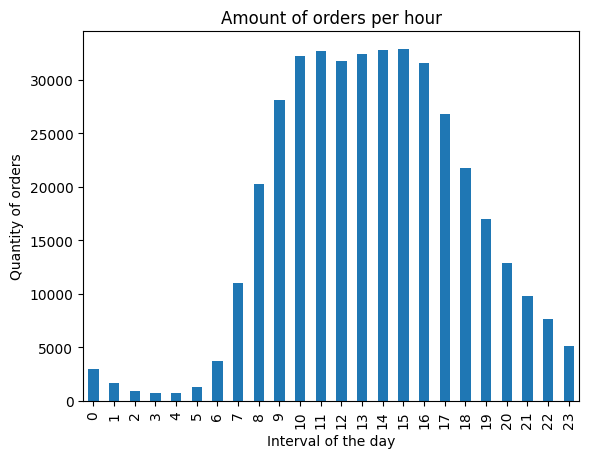

In [38]:


orders_per_hour = inst_orders_df.groupby("order_hour_of_day")["user_id"].nunique() # se cambia el código para que cuente por user_id
orders_per_hour.plot(kind="bar", 
                     title="Amount of orders per hour",
                     xlabel="Interval of the day",
                     ylabel="Quantity of orders") 
plt.show()



<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta pregunta pide el número de *personas* que realizan pedidos por hora, pero el código está contando pedidos (filas) por hora. Considera agrupar por hora y contar valores únicos de `user_id` para que coincida con lo que pide el enunciado.

</div>


Escribe aquí tus conclusiones

- La gráfica muestra varias tendencias en las diferentes jornadas del día. El primero y más relevante es el pico de las 10 am pero, sobre todo, como se presenta un trend de crecimiento desde muy temprano en la mañana, casi que duplicando en algunos casos el intervalo anterior en cuanto a cantidad de órdenes
- La segunda tendencia que veo es en la tarde, esta vez no de crecimiento necesariamente pero sí de constancia hasta que empieza a caer la tarde sobre las 17 horas
- Este análisis se pudiera complementar con 2 factores adicionales (1. el día de la semana, 2. el tipo de producto que se ordena) al ser una plataforma de entrega de comestibles no necesariamente relacionada con comida preparada, se evidencia una tendencia de compra volcada hacia fines de semana. Otro factor particular que valdria la pena considerar es el tipo de cliente. Por la misma naturaleza del producto que se vende, es altamente probable que el cliente final sea mayoritariamente la ama de casa que está abasteciendo su despensa para los próximos días
- En términos generales la tendencia por hora está correlacionada con el horario de actividad humana, es decir, ni tan temprano en la mañana ni tan tarde en la noche, teniendo picos en ciertos intervalos pero no con una diferencia significativa entre ellos

### [A3] ¿Qué día de la semana compran víveres las personas?

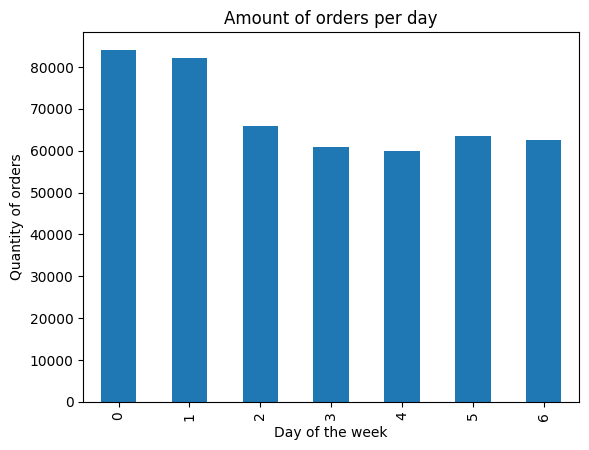

In [39]:
orders_per_hour = inst_orders_df.groupby("order_dow")["order_dow"].count()
orders_per_hour.plot(x="index",
                     y="order_dow", 
                     kind="bar", 
                     title="Amount of orders per day",
                     xlabel="Day of the week",
                     ylabel="Quantity of orders") 
plt.show()

Escribe aquí tus conclusiones

- El domingo es el día con más órdenes y, el lunes le sigue en cantidad de registros. Acá la tendencia puede estar fuertemente relacionada con los hábitos de consumo de la gente en fin de semana, siendo los días domingos los días donde las personas suelen descansar de su actividad laboral, dedicando tiempo a pasar en familia o actividades sociales, además de aprovechar espacios para la planeación y abastecimiento de recursos. Esta es la razón por la que los supermercados se encuentran más llenos en estos días de fin de semana y, por ende, las plataformas como Instacart, pueden tener mayor actividad
- Contrario a la hipótesis del punto anterior, el día lunes tiene una participación importante respecto a los demás días, es el segundo día con mayor participación después del domingo. Esto debe ser analizado con un poco más de profundidad para entender el comportamiento puntul de este día, investigar más a detalle horas específicas en las que se ordena, género del usuario, edad, locación. Todos estos factores pueden ofrecer un contexto más amplio de lo que sucede en realidad en este día

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64


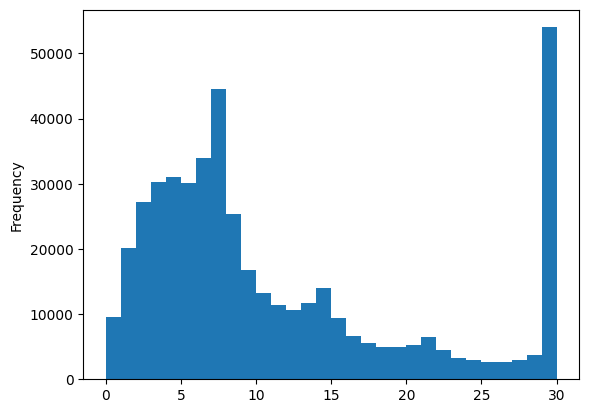

In [40]:
print(inst_orders_df["days_since_prior_order"].describe())
inst_orders_df["days_since_prior_order"].plot(kind="hist",bins=30) # Se incluye gráfico para ilustrar la distribución de contenedores en grupos de días para ordenar de nuevo
plt.show()


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta tarea pide un *plot* de `days_since_prior_order` (distribución del tiempo de espera). Ahora mismo solo muestras `describe()`. Considera añadir un histograma/gráfico de barras y luego comentar sobre el mínimo/máximo usando la distribución (y señalando el contexto, como que faltan los primeros pedidos, y que 30 parece ser un límite (*cap*) del dataset).

</div>



Escribe aquí tus conclusiones

- En promedio las personas esperan 11 días para ordenar nuevamente. Llegando hasta 30 días máximo para volver a pedir.
- Podemos apreciar que el 75% de la población espera 15 día o menos para volver a hacer una orden
- Respecto a los niveles mínimos y máximos, podemos apreciar que mínimo es 0, llegando a pedir nuevamente dentro de las primeras 24 horas a partir de la fecha y hora de su orden previa, hasta 30 días. Es un umbral amplio que no refleja necesariamente el comportamiento mayoritario del grupo poblacional, puesto que la desviación estandar es apenas de 7 días siendo una media de 11 días, lo que quiere decir que, si graficáramos en un diagrama de dispersión, encontraríamos unabasta acumulación de las muestras entre 4 y 18 días. Un umbral mucho más reducido y que sí refleja en gran medida el comportamiento general de los usuarios de la plataforma
- Es importante mencionar que el tope de 30 días parace ser un extremo del umbral establecido en el dataset de manera predeterminada, probablemente para tiempos superiores a esa cantidad de días
- Esta información nos puede ser muy útil para tomar decisiones de negocio al complementar el estudio con otros aspectos, además de los mencionados anteriormente con el tipo de población, con los aspectos socio económicos que pueden jugar un papel importante para hacer campañas de mercadeo sectorizadas que permitan aumentar las probabilidades de éxito en el objetivo de incentivar el uso de la plataforma, así como incluir aliados estratégicos que solventen las diversas necesidades de nuestros usuarios

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

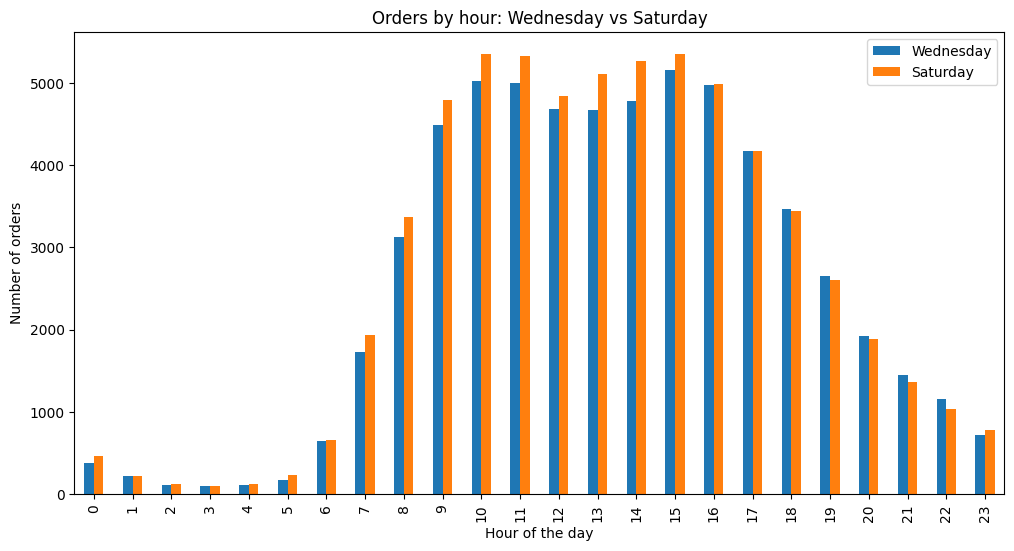

In [41]:
# Filtramos el Dataframe original para obtener solo los registros de miércoles y sábado
wed_sat_data = inst_orders_df[(inst_orders_df["order_dow"]==3) | (inst_orders_df["order_dow"]==5)]

# Creamos un objeto Series para cada uno de los días
wed_data = wed_sat_data[wed_sat_data["order_dow"]==3].groupby("order_hour_of_day").size()
sat_data = wed_sat_data[wed_sat_data["order_dow"]==5].groupby("order_hour_of_day").size()

# Combinamos en un DataFrame los objetos Series que creamos antes, a través de un diccionario colocando como clave el valor del día y como valor el Series con la data filtrada
combined_data = pd.DataFrame({'Wednesday': wed_data,'Saturday': sat_data})


combined_data.plot(kind="bar",
                   title="Orders by hour: Wednesday vs Saturday",
                   xlabel="Hour of the day",
                   ylabel="Number of orders",
                   figsize=(12, 6))
plt.show()


## Análisis de gráfica
- Se pueden observar diferencias en cuanto a cantidad entre ambos días, siendo el sábado el día con mayor cantidad de órdenes en los intervalos de medio día hasta las 17, donde la tendencia se invierte a los miércoles con mayor cantidad de órdenes
- La mayor diferencia entre ambos días se da en los intervalos del medio día, inclusive desde las 10 am donde se marca de manera prominente el sábado sobre el miércoles

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

La participación acumulada de los usuarios que hacen entre 1 y 4 pedidos es 80.61%


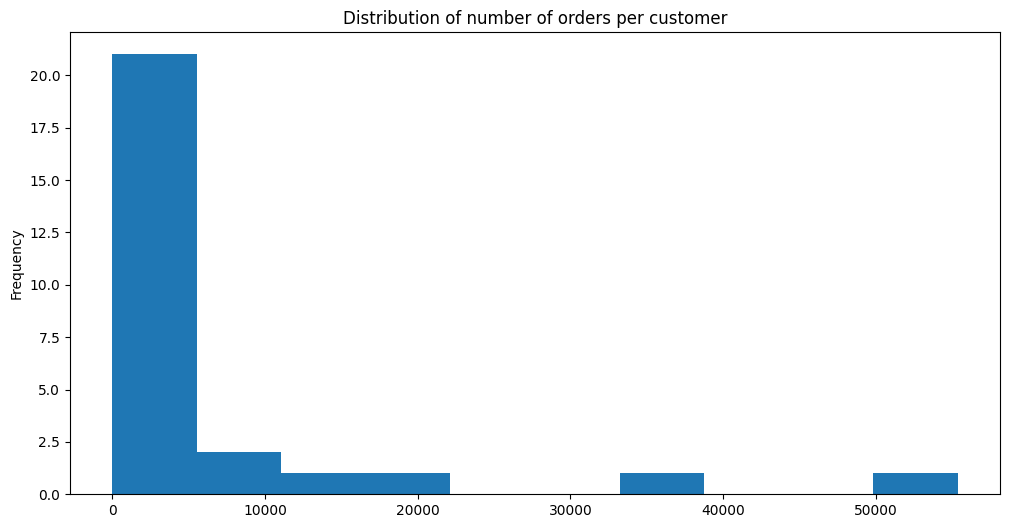

In [42]:
# agrupamos por user_id el DataFrame, para saber cuántas veces pide cada uno y usamos el método size() para contar la cantidad dde filas por grupo
orders_per_customer = inst_orders_df.groupby("user_id").size()

# contamos la cantidad de veces que se repite cada valor único con value_counts y luego ordenamos de menos a mayor esa concurrencia, esto lo almacenamos en una variable
customer_distribution = orders_per_customer.value_counts().sort_index()
# Vamos a contabilizar el total de usuarios
total_users = customer_distribution.sum()
# Ahora calculamos el porcentaje de usuarios que realizan x cantidad de órdenes vs el total de usuarios
customer_percentages = (customer_distribution / total_users) * 100
# calculamos la participación acumulada de las distribuciones del 1 al 4
cumulative_percentage = (customer_percentages.iloc[0]+customer_percentages.iloc[1]+customer_percentages.iloc[2]+customer_percentages.iloc[3])
print(f"La participación acumulada de los usuarios que hacen entre 1 y 4 pedidos es {cumulative_percentage:.2f}%")

customer_distribution.plot(kind="hist",
                          title="Distribution of number of orders per customer",
                          xlabel="Number of orders",
                          ylabel="Number of customers",
                          figsize=(12, 6)) # es necesario asignarle dimensiones o quedaría muy chico el gráfico con los valores por defecto
plt.show()

# Se genera histograma en lugar de gráfico de barras para facilitar comprensión


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La distribución de pedidos por cliente es difícil de interpretar como un gráfico de barras con muchas categorías. Considera usar un histograma (o agrupar en rangos) para que la forma general de la distribución sea legible.

</div>


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Aquí hay una celda de código vacía adicional. Considera eliminarla o usarla para una salida de apoyo (p. ej., una pequeña tabla resumen o un cálculo de porcentaje acumulado al que hagas referencia en tu conclusión).

</div>


Escribe aquí tus conclusiones
- La distribución de la cantidad de órdenes por usuario se vuelva hacia que al rededor del 80% de los mismos, ordenan entre 1 y 4 veces, de alguna manera podemos deducir que aquí está el Pareto

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La afirmación de que “~80% de los usuarios hacen pedidos 1–4 veces” no está respaldada por un cálculo mostrado. Considera calcular la proporción acumulada a partir de `customer_distribution` y reportar el porcentaje exacto para sustentar esta afirmación.

</div>


### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [43]:
# Creamos una variable que almacene un DataFrame fusionado entre products_df y order_products_df para tener el id y el nombre del producto a partir
# de los productos incluidos en órdenes
merged_products_and_order_products_df = order_products_df.merge(products_df, on="product_id", how="inner") # hacemos el merge de tipo "inner" para mantener solo las coincidencias en ambos DataFrames a partir del product_id
# Agrupamos y contamos las filas del nuevo DataFrame, además de ordenarlos de manera descendente (esto arroja un objeto tipo Series)
grouped_by_product = (merged_products_and_order_products_df.groupby(["product_id","product_name"]).size()).sort_values(ascending=False)
# Reseteamos los índices y extraemos el top 20 para crear un DataFrame del objeto Series arrojado por la agrupación en grouped_by_product
top_20_products = grouped_by_product.head(20).reset_index()
# Asignamos nombres a las columnas del nuevo DataFrame
top_20_products.columns = ["product_id", "product_name", "count"]
# imprimimos el DataFrame pero excluimos el conteo realizado arriba con size()
print(top_20_products.loc[:,["product_id", "product_name"]])


    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        47626               Large Lemon
7        16797              Strawberries
8        26209                     Limes
9        27845        Organic Whole Milk
10       27966       Organic Raspberries
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       39275       Organic Blueberries
15       49683            Cucumber Kirby
16       28204        Organic Fuji Apple
17        5876             Organic Lemon
18        8277  Apple Honeycrisp Organic
19       40706    Organic Grape Tomatoes


Escribe aquí tus conclusiones

- Los productos dentro del top 20 de más pedidos son productos clasificados como "orgánicos", principalmente frutas y, por amblia diferencia, las bananas ocupan los lugares 1 y 2 en un par de distintas presentaciones.
- Podríamos decir que el top 3 de productos mayormente comercializados es: 1. Banana, 2, Fresas y 3, Aguacate. Lo cual coincide con una tendencia que vimos líneas arriba en la que se evidenciaba una tendencia en la que el 75% de los usuarios tienen un promedio de espera entre órdenes de 15 días o menos. Al ser productos que se prefieren frescos y tienen un tiempo de vida corto a partir de su madurez

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Trabajo claro y completo al identificar los 20 productos pedidos con mayor frecuencia: hiciste el merge correctamente, generaste la salida requerida `product_id` + `product_name`, y ofreciste una interpretación razonable de lo que más destaca en los resultados.

</div>



# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

        order_id  products_per_order
0          61355                 127
1        3308010                 115
2        2136777                 108
3         171934                 104
4        1959075                  98
...          ...                 ...
450041   2231165                   1
450042    816908                   1
450043   2230951                   1
450044    112056                   1
450045   3421079                   1

[450046 rows x 2 columns]


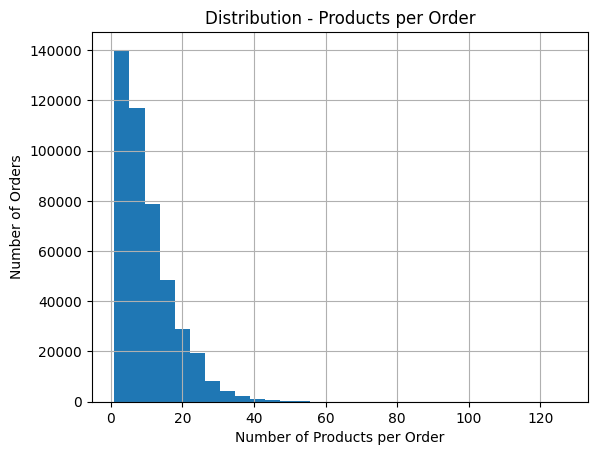

In [44]:
# Creamos una variable que almacene la agrupación por order_id, contamos y ordenamos para mejorar la visual
grouped_by_order_id = order_products_df.groupby("order_id")["product_id"].count().sort_values(ascending=False).reset_index()
grouped_by_order_id.columns = ["order_id", "products_per_order"]
print(grouped_by_order_id) # imprimimos resultado para asegurar que es lo que esperamos (Order_id vs cantidad de productos)
grouped_by_order_id["products_per_order"].hist(bins=30)
plt.title("Distribution - Products per Order")
plt.xlabel("Number of Products per Order")
plt.ylabel("Number of Orders")
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta sección pide la *distribución* de artículos por pedido. Calculaste los conteos y las estadísticas de resumen, pero considera añadir un histograma/gráfico de barras de artículos-por-pedido para que sea fácil ver el sesgo, el rango típico y la cola larga.

</div>


In [45]:
# Extraemos la información estadística de la agrupación recientemente hecha
describe_orders = grouped_by_order_id.describe()
print(describe_orders)

           order_id  products_per_order
count  4.500460e+05       450046.000000
mean   1.710656e+06           10.098983
std    9.866356e+05            7.540206
min    4.000000e+00            1.000000
25%    8.576508e+05            5.000000
50%    1.710965e+06            8.000000
75%    2.563452e+06           14.000000
max    3.421079e+06          127.000000


Escribe aquí tus conclusiones

- Tenemos un promedio de 10 productos por orden, una desviación estandar de 7,5 productos y un rango entre 1 y 127 productos por orden, esto habla de una disperción significativa entre extremos, por lo que existen outliers en este comportamiento pero no son la parte mayoritaria
- Surge una hipótesis de que las órdenes con menor cantidad de productos podrían ser órdenes primerizas de usuarios nuevos que quieren probar la plataforma o meramente sentido de urgencia de algunos usuarios por productos que necesitan con inmediatez
- También este comportamiento que vemos en la distribución puede estar relacionado con el tipo de productos, ya vimos que en su mayoría son frutas, entre bananas y fresas, este es un comportamiento de abastecimiento probablemente acorde a los hábitos alimenticios de las personas
- Ya establecimos que el 80% de las órdenes tienen entre 1 y 4 productos, estableciendo la cola del histograma de forma extendida hacia la derecha del gráfico y teniendo un pico de cerca de 140000 órdenes dentro del umbral previamente mencionado

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [46]:
# filtramos por los productos que han sido reordenados más de una vez
reordered_products = order_products_df[order_products_df["reordered"]==1]
# agrupamos y dimencionamos con size, además ordenamos de mayor a menos y reseteamos índices para convertir en DataFrame el Series obtenido
grouped_reordered = reordered_products.groupby(["product_id"]).size().sort_values(ascending=False).reset_index()
grouped_reordered.columns = ['product_id', 'reorder_count']  # nombramos las columnas
# fusionamos con products para tener los nombres de los productos
merged_reordered_and_products_df = grouped_reordered.merge(products_df, on="product_id", how="inner")
# Creamos el top 20 e indexamos para mostrar solo id y nombre
top_20_reordered_products = merged_reordered_and_products_df.head(20).loc[:,["product_id", "product_name"]]
print(top_20_reordered_products) # imprimimos resultado

    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        27845        Organic Whole Milk
7        47626               Large Lemon
8        27966       Organic Raspberries
9        16797              Strawberries
10       26209                     Limes
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       49683            Cucumber Kirby
15       28204        Organic Fuji Apple
16        8277  Apple Honeycrisp Organic
17       39275       Organic Blueberries
18        5876             Organic Lemon
19       49235       Organic Half & Half


Escribe aquí tus conclusiones

- Los resultados, como se esperaba, son muy similares al top 20 de productos más ordenados, esto sugiere una buena relación precio-calidad en cuanto a la oferta de la plataforma
- También el factor precio, respecto a estos productos, es probablemente favorable respecto a la expectativa del usuario final vs otras alternativas locales y de otras plataformas
- existen variaciones en las pocisiones de este top 20 vs el top 20 de productos más ordenados, a excepción del top 5, lo que indica que la tasa de reordenamiento de los primeros 5 productos es más alta que los demás y, por ende, no hay cambios en el orden de estos, a diferencia de los 15 restantes donde sí hay variaciones

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [47]:
"""
Este código calcula la tasa de 're-ordenamiento' de cada producto
devuelve: product_id, product_name y reordered_rate en un DataFrame
"""
# primero agrupamos por product_id la cantidad de órdenes realizadas por cada producto
total_ordered_per_product = order_products_df.groupby("product_id")["order_id"].size().reset_index()
# Asigamos nombres de columnas
total_ordered_per_product.columns = ["product_id", "total_ordered"]
# contamos cantidad de veces que se re-ordenó cada producto
total_reordered_per_product = order_products_df.groupby("product_id")["reordered"].sum().reset_index()
# asignamos headers nuevamente
total_reordered_per_product.columns = ["product_id", "reordered_count"]
# combinamos DFs
merged_ordered_and_reordered = total_reordered_per_product.merge(total_ordered_per_product, on="product_id", how="inner")
# asignamos nombres de columnas al DF merged
merged_ordered_and_reordered.columns = ["product_id", "reordered","total_ordered"]
# creamos nueva columna para calcular el re-ordered rate
merged_ordered_and_reordered["reordered_rate"] = (merged_ordered_and_reordered["reordered"] / merged_ordered_and_reordered["total_ordered"]) # Se elimina multiplicación por 100 para mostrar resultados entre 0 y 1 según sugerencia del bot
# hacemos un nuevo merge pero esta vez con products_df para traer el nombre de cada producto
final_merge = merged_ordered_and_reordered.merge(products_df, on="product_id" , how="inner")
# Asignamos por última vez nombres de columnas para el DF final
final_merge.columns = ["product_id", "reordered","total_ordered", "reordered_rate", "product_name", "aisle_id", "department_id", "product_name_mayus"]
# imprimimos solo las columnas que queremos mostrar con indexación usando loc
print(final_merge.loc[:,["product_id", "product_name","reordered_rate"]])

       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               7                     Pure Coconut Water With Orange   
...           ...                                                ...   
45568       49690                      HIGH PERFORMANCE ENERGY DRINK   
45569       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
45570       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
45571       49693                             SPRING WATER BODY WASH   
45572       49694                            BURRITO- STEAK & CHEESE   

       reordered_rate  
0            0.564286  
1            0.000000  
2            0.738095  
3            0.510204  
4            0.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para [C3], el enunciado solicita una *proporción* de reordenes por producto (un valor entre 0 y 1). Tu `reordered_rate` se multiplica por 100, convirtiéndolo en un porcentaje. Considera alinear la métrica con las instrucciones y etiquetar claramente las columnas de salida como `product_id`, `product_name` y la proporción de reorden.

</div>


In [52]:
"""Vamos a crear una función para luego usar el método apply y aplicar la función a cada registro, así categorizaremos, 
a partir del reordered_rate, cada registro, para luego contabilizar por categoría la distribución y analizar más a detalle
estos resultados
"""
def categorize_reorder_rate(rate):
    if rate == 0.0:
        return "No_reordered (0%)"
    elif rate <= 0.3:
        return "Low_reorder_rate (1-30%)"
    elif rate <= 0.6:
        return "Moderate_reorder_rate (31-60%)"
    elif rate <= 0.8:
        return "High_reorder_rate (61-80%)"
    else:
        return "very_high_reorder_rate (81-100%)"

# Categorizamos
final_merge['reorder_category'] = final_merge['reordered_rate'].apply(categorize_reorder_rate)

# Contamos productos por categoría
category_counts = final_merge['reorder_category'].value_counts()
print("Distribución de productos por categoría de reordenamiento:")
print(category_counts)
print()

# Calculamos porcentajes por categoría
category_percentages = (category_counts / len(final_merge)) * 100 # Cada categoría, se divide por la longitud del DataFrame final_merge y obtenemos el porcentaje de reordenamiento por cada bucket que creamos
print("Porcentajes por categoría:")
for category, percentage in category_percentages.items(): # Creamos un bucle que cree el f-string a imprimir a partir del calculo en category_percentages + un string de complemento
    print(f"{category}: {percentage:.2f}%")

Distribución de productos por categoría de reordenamiento:
Moderate_reorder_rate (31-60%)      19167
No_reordered (0%)                    9345
Low_reorder_rate (1-30%)             7379
High_reorder_rate (61-80%)           7304
very_high_reorder_rate (81-100%)     2378
Name: reorder_category, dtype: int64

Porcentajes por categoría:
Moderate_reorder_rate (31-60%): 42.06%
No_reordered (0%): 20.51%
Low_reorder_rate (1-30%): 16.19%
High_reorder_rate (61-80%): 16.03%
very_high_reorder_rate (81-100%): 5.22%


Escribe aquí tus conclusiones

- El 42.06% de productos tienen reordenamiento moderado (31-60%), lo que puede sugerir satisfacción general del cliente con la oferta disponible
- Los productos se dividen claramente entre alta fidelidad (21.25% con >60% reorden) como productos básicos, y productos de prueba única (20.51% sin reorden)
- El 36.7% de productos con baja/nula reordenación representa una oportunidad estratégica para optimizar precios, calidad y marketing dirigido

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Las conclusiones para [C3] están vacías. Considera añadir una breve interpretación de las proporciones de recompra por producto (p. ej., rango/forma típicos y lo que podrían implicar proporciones de recompra altas vs. bajas), y opcionalmente destacar un par de ejemplos relevantes.

</div>


### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [57]:
"""Para cada cliente, ¿qué proporción de los productos que pidió ya
los había pedido? Calcula la tasa de repetición de pedido para cada
usuario en lugar de para cada producto."""
# Primero combinamos 2 DataFrames para tener toda la info en un solo lugar
inst_and_products_df = order_products_df.merge(inst_orders_df, on="order_id", how="inner")
# Agrupamos por user_id para calcular total de órdenes por usuario
orders_per_user = inst_and_products_df.groupby("user_id")["product_id"].size().sort_values(ascending=False).reset_index()
# Ahora calculamos la cantidad de veces que ha re-ordenado productos mediante agrupación
reordered_per_user = inst_and_products_df.groupby("user_id")["reordered"].sum().reset_index()
# Fusionamos los 2 DataFrames obtenidos
user_id_and_total_orders = reordered_per_user.merge(orders_per_user, on="user_id", how="inner")
# Asignamos nombres a las columnas
user_id_and_total_orders.columns = ["user_id", "sum_reordered", "total_orders"]
# creaamos nueva columna para calcular el reordered rate por usuario
user_id_and_total_orders["reordered_rate_per_user"] = user_id_and_total_orders["sum_reordered"] / user_id_and_total_orders["total_orders"] * 100
user_id_and_total_orders.columns = ["user_id", "count_reordered_articles", "total_buyed_articles", "reordered_rate_per_user"] # Se ajustan nombres de columnas para mayor claridad
print(user_id_and_total_orders) # imprimimos resultado
# Obtenemos medidas estadísticas del consolidado por usuario
print(user_id_and_total_orders.describe())

        user_id  count_reordered_articles  total_buyed_articles  \
0             2                         1                    26   
1             4                         0                     2   
2             5                         8                    12   
3             6                         0                     4   
4             7                        13                    14   
...         ...                       ...                   ...   
149621   206203                         6                    27   
149622   206206                        15                    21   
149623   206207                        41                    46   
149624   206208                        87                   125   
149625   206209                         8                    25   

        reordered_rate_per_user  
0                      3.846154  
1                      0.000000  
2                     66.666667  
3                      0.000000  
4                     92.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Calculas una tasa de recompra por usuario usando el recuento de artículos reordenados dividido por el total de artículos, pero la columna del denominador se llama `total_orders`, lo cual es engañoso. Considera renombrar variables/columnas para reflejar lo que realmente representan (p. ej., total de artículos comprados) y describir explícitamente la métrica como “artículos reordenados / total de artículos comprados” por usuario.

</div>


Escribe aquí tus conclusiones

- La tasa promedio de reordenamiento por usuario es del 49.5%, esto sugiere un balance saludable entre usuarios ocasionales y frecuentes en la plataforma
- El 25% de usuarios (Q1) tiene tasas de reordenamiento inferior o igual a 27%, mientras que el 25% superior (Q3) supera el 72%, permitiendo estrategias diferenciadas de retención y activación según el perfil de fidelidad y la estrategia de la compañía
- Los usuarios con mayor cantidad de artículos comprados (Q3: >38 artículos) muestran tasas de reordenamiento más altas, sugiriendo que la satisfacción aumenta con la experiencia de uso de la plataforma
- Con un rango completo de 0-100% en tasas de reordenamiento y una mediana del 50%, existe potencial significativo para mejorar la fidelización de usuarios mediante estrategias personalizadas basadas en su historial de compras.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La interpretación de los cuartiles es inconsistente (p. ej., “25% (Q4)”). Considera usar la terminología estándar: Q1 = percentil 25, mediana (Q2) = 50, Q3 = 75, y luego reformular qué significan esos valores para las proporciones de reorden de los usuarios.

</div>


### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [58]:
""" ¿Cuáles son los 20 principales artículos que la gente pone
primero en sus carritos (muestra las IDs de los productos, sus nombres,
y el número de veces en que fueron el primer artículo en añadirse al carrito)?"""
# usamos el DataFrame creado anteriormente "merged_products_and_order_products_df" para definir top 20
# Filtramos los artículos que han sido ordenados en primer lugar usando un query
filtered_per_1st_place = merged_products_and_order_products_df.query("add_to_cart_order == 1")
# contamos las veces que cada valor único aparece en la columna "product_id" y reseteamos el índice para obtener un DataFrame
product_counts = filtered_per_1st_place["product_id"].value_counts().reset_index()
# Asignamos nombres a las columnas
product_counts.columns = ["product_id", "first_added_count"] # Se corrije nombre de la segunda columna
# volvemos a usar merge para traer el nombre del producto
final_result = product_counts.merge(products_df[["product_id", "product_name"]], on="product_id")
top_20 = final_result.head(20)
print(top_20) # imprimimos resultado final

    product_id  first_added_count                 product_name
0        24852              15562                       Banana
1        13176              11026       Bag of Organic Bananas
2        27845               4363           Organic Whole Milk
3        21137               3946         Organic Strawberries
4        47209               3390         Organic Hass Avocado
5        21903               3336         Organic Baby Spinach
6        47766               3044              Organic Avocado
7        19660               2336                 Spring Water
8        16797               2308                 Strawberries
9        27966               2024          Organic Raspberries
10       44632               1914   Sparkling Water Grapefruit
11       49235               1797          Organic Half & Half
12       47626               1737                  Large Lemon
13         196               1733                         Soda
14       38689               1397     Organic Reduced F

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo generando la tabla solicitada del top-20 con IDs, nombres y conteos. Una pequeña mejora: considera renombrar la columna de conteo para evitar un “#” al inicio (por ejemplo, `first_added_count`), ya que es más claro y suele funcionar mejor con el procesamiento/exportación posterior.

</div>


Escribe aquí tus conclusiones

- Como era de esperarse, basado en los resultados de los anteriores top 20s, las bananas son el primer producto en ser agregado al carrito a la hora de ordenarlo. Las bananas fueron agregadas como primer producto al carrito 15562 veces, seguidas por las bananas orgánicas con 11026 veces. La leche orgánica ocupa el tercer lugar con 4363 veces, mostrando una diferencia significativa donde las bananas regulares superan por más de 3.5 veces al tercer producto más agregado primero
- Esta dominancia de las bananas (15562 vs 4363 = 356% más que el tercer lugar) puede hablar de su calidad, precio competitivo y disponibilidad constante, además de la eficiencia en la logística que permite que los usuarios vuelvan a ordenar. El hecho de que los dos primeros lugares sean variaciones del mismo producto (bananas) con un total combinado de 26588 veces como primer artículo agregado, confirma su posición como producto ancla en la plataforma
- Los primeros 5 productos (bananas, bananas orgánicas, leche orgánica, fresas orgánicas y aguacate orgánico) acumulan 38321 veces como primer artículo agregado, representando el 55.8% del total de los primeros 20 productos, lo que confirma que los usuarios priorizan productos de consumo diario y alta rotación
- Aunque las frutas dominan el top 20, aparecen 4 productos diferentes (leche orgánica, agua, leche reducida en grasa y half & half) entre dicho top. Totalizando 9302 veces como primer producto agregado, demostrando que los usuarios también priorizan productos básicos de despensa junto con productos frescos

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para cumplir plenamente con el requisito de interpretación, considera hacer referencia a algunos recuentos concretos de tus resultados (p. ej., cuántas veces los productos #1 y #2 fueron los primeros en añadirse), en lugar de limitarte a comparaciones relativas.

</div>


### Conclusion general del proyecto:

## Resumen Ejecutivo

El análisis del dataset de Instacart reveló patrones de comportamiento claros en los hábitos de compra de comestibles online, identificando oportunidades estratégicas para optimización de inventario, marketing dirigido y mejora de la experiencia del usuario.

### Hallazgos Principales por Categoría

#### Patrones Temporales:

- Horarios pico: Las órdenes se concentran entre las 10 AM y 17 PM, con el pico máximo a las 10 AM
- Días preferidos: Domingo es el día con mayor actividad (comportamiento típico de abastecimiento familiar), seguido sorprendentemente por lunes
- Diferencias miércoles vs sábados: Los sábados muestran mayor actividad en horarios de medio día (10 AM - 17 PM), mientras que los miércoles tienen mayor actividad en horarios nocturnos

#### Comportamiento del Cliente:

- Frecuencia de reorden: Promedio de 11 días entre órdenes, con 75% de usuarios reordenando en 15 días o menos
- Tamaño de órdenes: Promedio de 10 productos por orden, con alta variabilidad (rango 1-127 productos)
- Distribución de clientes: 80% de usuarios realizan entre 1-4 órdenes, sugiriendo alta rotación de clientes nuevos
- Tasa de reordenamiento por usuario: Media del 49.5%, con distribución equilibrada entre usuarios ocasionales y frecuentes

#### Análisis de Productos:

- Productos estrella: Bananas dominan en todas las categorías (más ordenado, más reordenado, más agregado primero al carrito)
- Categoría predominante: Productos orgánicos representan la mayoría del top 20, especialmente frutas y verduras frescas
- Productos de alta rotación: Coincidencia entre productos más ordenados y más reordenados, indicando satisfacción del cliente

#### Calidad de Datos y Limitaciones
- Duplicados identificados: 15 registros duplicados concentrados en miércoles 2 AM (posible falla del sistema)
- Valores ausentes: 6.02% en órdenes (clientes primerizos) y 2.53% en nombres de productos (categoría "missing")
- Decisiones de preprocesamiento: Valores ausentes reemplazados estratégicamente para preservar información analítica

### Recomendaciones Estratégicas
- Optimización de inventario: Priorizar stock de productos orgánicos, especialmente frutas frescas como bananas
- Marketing temporal: Concentrar campañas promocionales en domingos y horarios 10 AM - 17 PM
- Retención de clientes: Implementar estrategias para convertir usuarios de 1-4 órdenes en clientes frecuentes
- Gestión de productos "missing": Investigar y resolver problemas de categorización de 1,258 productos

### Impacto de Negocio

Los hallazgos sugieren una base de clientes orientada hacia productos saludables y orgánicos, con patrones de compra predecibles que permiten optimización operativa y estrategias de marketing dirigidas para incrementar la frecuencia de compra y el valor promedio por orden.